In [32]:
# Install Required Libraries
!pip install pandas numpy matplotlib seaborn plotly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [33]:
# Upload Dataset
from google.colab import files
uploaded = files.upload()
df1 = pd.read_csv("1.csv")
df2 = pd.read_csv("2.csv")
print("Dataset 1 Shape:", df1.shape)
print("Dataset 2 Shape:", df2.shape)

Saving 1.csv to 1.csv
Saving 2.csv to 2.csv
Dataset 1 Shape: (768, 7)
Dataset 2 Shape: (267, 9)


In [34]:
# Dataset Overview
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [35]:
df2.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [36]:
# Check dataset structure
df1.info()
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                  

In [40]:
df1.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [41]:
df2.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [43]:
# Check missing values
df1.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [44]:
df2.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Region.1,0
longitude,0
latitude,0


In [45]:
# Data Cleaning
# Remove unwanted spaces in column names
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [47]:
# Convert date column
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)

In [48]:
# Extract year and month
df1['Year'] = df1['Date'].dt.year
df1['Month'] = df1['Date'].dt.month

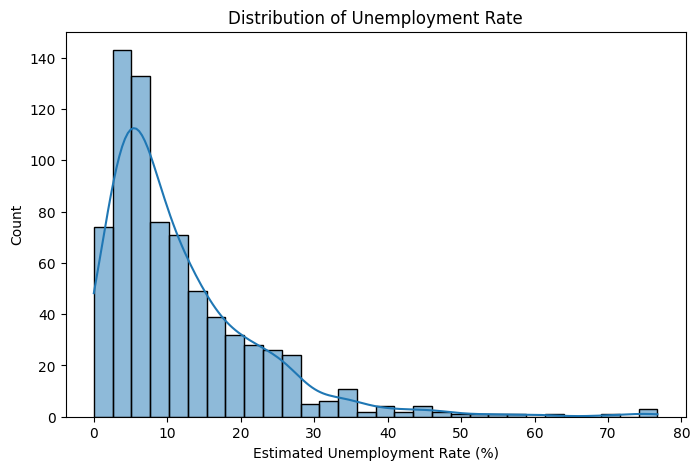

In [49]:
# Unemployment Rate Distribution
plt.figure(figsize=(8,5))
sns.histplot(df1['Estimated Unemployment Rate (%)'], bins=30, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

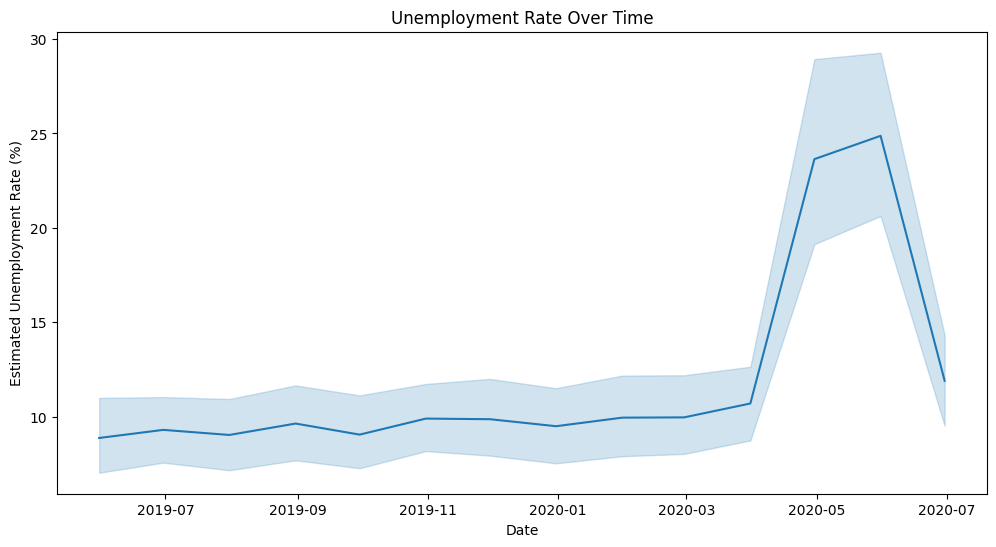

In [50]:
# Unemployment Rate Over Time
plt.figure(figsize=(12,6))
sns.lineplot(
    x="Date",
    y="Estimated Unemployment Rate (%)",
    data=df1
)
plt.title("Unemployment Rate Over Time")
plt.show()

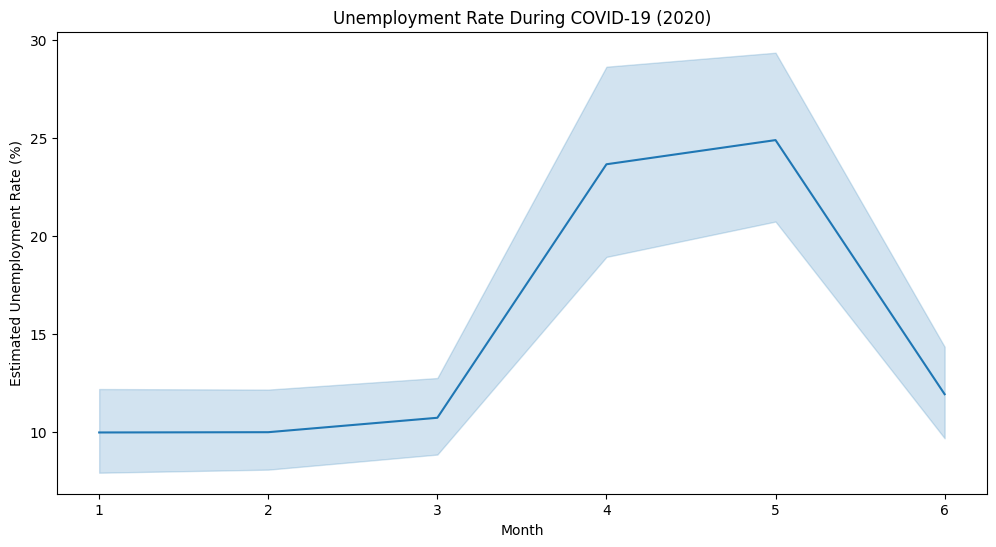

In [51]:
# COVID Impact Analysis
covid_data = df1[df1['Year'] == 2020]
plt.figure(figsize=(12,6))
sns.lineplot(
    x="Month",
    y="Estimated Unemployment Rate (%)",
    data=covid_data
)
plt.title("Unemployment Rate During COVID-19 (2020)")
plt.show()

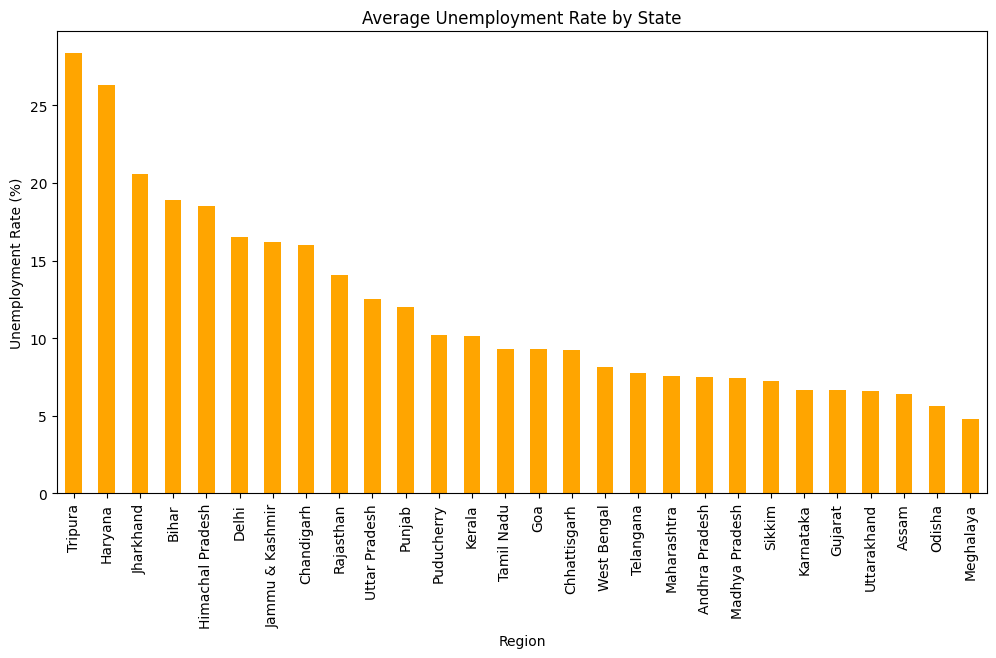

In [52]:
# State-wise Unemployment Analysis
state_unemployment = df1.groupby("Region")[
    "Estimated Unemployment Rate (%)"
].mean().sort_values(ascending=False)
state_unemployment.plot(
    kind="bar",
    figsize=(12,6),
    color="orange"
)
plt.title("Average Unemployment Rate by State")
plt.ylabel("Unemployment Rate (%)")
plt.show()

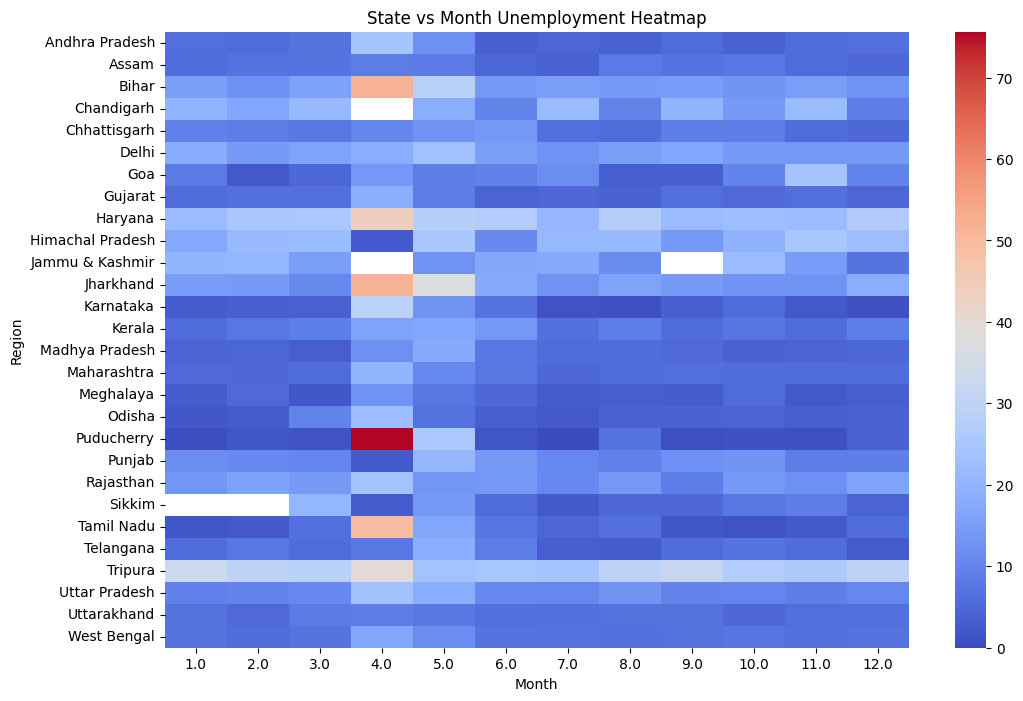

In [53]:
# Heatmap Visualization
pivot_table = df1.pivot_table(
    values="Estimated Unemployment Rate (%)",
    index="Region",
    columns="Month"
)
plt.figure(figsize=(12,8))
sns.heatmap(pivot_table, cmap="coolwarm")
plt.title("State vs Month Unemployment Heatmap")
plt.show()

In [54]:
# Interactive Plot
fig = px.line(
    df1,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    color="Region",
    title="Unemployment Rate Trend by Region"
)
fig.show()

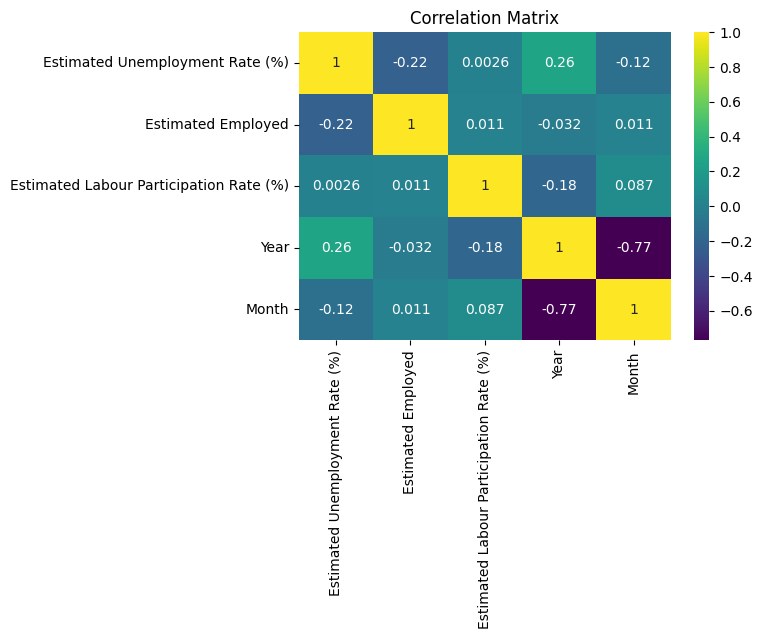

In [55]:
# Correlation Analysis
plt.figure(figsize=(6,4))
sns.heatmap(df1.corr(numeric_only=True), annot=True, cmap="viridis")
plt.title("Correlation Matrix")
plt.show()

**Key Insights**

• Unemployment increased significantly during 2020 due to COVID-19.

• Some regions experienced much higher unemployment than others.

• There is seasonal variation in unemployment rates.

• The lockdown months show the highest spikes.

In [57]:
# Streamli App
# Install Required Libraries
!pip install streamlit pandas numpy plotly seaborn pyngrok

In [60]:
# Create the Streamlit App File
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
st.set_page_config(page_title="Unemployment Analysis Dashboard", page_icon="📊", layout="wide")

# Load Data
@st.cache_data
def load_data():
    df1 = pd.read_csv("1.csv")
    df2 = pd.read_csv("2.csv")
    df1.columns = df1.columns.str.strip()
    df2.columns = df2.columns.str.strip()
    df1["Date"] = pd.to_datetime(df1["Date"], dayfirst=True)
    df1["Year"] = df1["Date"].dt.year
    df1["Month"] = df1["Date"].dt.month
    return df1, df2
df1, df2 = load_data()

# Sidebar Filters
st.sidebar.title("Filters")
region_options = sorted(df1["Region"].dropna().unique())
year_options = sorted(df1["Year"].dropna().unique())
regions = st.sidebar.multiselect(
    "Select Region",
    options=region_options,
    default=region_options
)
years = st.sidebar.multiselect(
    "Select Year",
    options=year_options,
    default=year_options
)
filtered_df = df1[
    (df1["Region"].isin(regions)) &
    (df1["Year"].isin(years))
]
if filtered_df.empty:
    st.warning("No data available for selected filters.")
    st.stop()

# Title
st.title("📊 Unemployment Analysis Dashboard")
st.markdown("Analysis of unemployment trends and the impact of COVID-19.")
st.divider()

# KPI Section
col1, col2, col3 = st.columns(3)
avg_unemployment = filtered_df["Estimated Unemployment Rate (%)"].mean()
max_unemployment = filtered_df["Estimated Unemployment Rate (%)"].max()
min_unemployment = filtered_df["Estimated Unemployment Rate (%)"].min()
col1.metric("Average Unemployment Rate", f"{avg_unemployment:.2f}%")
col2.metric("Maximum Rate", f"{max_unemployment:.2f}%")
col3.metric("Minimum Rate", f"{min_unemployment:.2f}%")
st.divider()

# Unemployment Trend
st.subheader("📈 Unemployment Trend Over Time")
fig_trend = px.line(
    filtered_df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    color="Region",
    title="Unemployment Rate by Region"
)
st.plotly_chart(fig_trend, use_container_width=True)

# State Comparison
st.subheader("📊 State-wise Average Unemployment")
state_avg = filtered_df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().reset_index()
fig_state = px.bar(
    state_avg,
    x="Region",
    y="Estimated Unemployment Rate (%)",
    color="Region",
    title="Average Unemployment Rate by Region"
)
st.plotly_chart(fig_state, use_container_width=True)

# COVID Impact
st.subheader("🦠 COVID-19 Impact Analysis (2020)")
covid_data = filtered_df[filtered_df["Year"] == 2020]
fig_covid = px.line(
    covid_data,
    x="Month",
    y="Estimated Unemployment Rate (%)",
    color="Region",
    title="Unemployment During COVID-19"
)
st.plotly_chart(fig_covid, use_container_width=True)

# Data Table
st.subheader("📄 Dataset Preview")
st.dataframe(filtered_df)

# Insights Section
st.subheader("📌 Key Insights")
st.markdown("""
• Unemployment rates increased significantly during 2020 due to COVID-19.

• Some regions experienced much higher unemployment compared to others.

• Lockdown months show the largest spikes in unemployment.

• Economic recovery can be observed in later months.
""")

Writing app.py


In [61]:
# Launch Streamlit
from pyngrok import ngrok
import time
import os
# Kill existing tunnels
ngrok.kill()
# Start Streamlit server
!streamlit run app.py --server.port 8501 --server.headless true &>/content/logs.txt &
# Wait for server to start
time.sleep(5)
# Create public tunnel
public_url = ngrok.connect(8501)
print("🌍 Open this URL:", public_url)

🌍 Open this URL: NgrokTunnel: "https://103d-34-6-90-189.ngrok-free.app" -> "http://localhost:8501"
